# BERT Duplicate Question Detection (QQP)

Detects whether two Quora questions are paraphrases using `bert-base-uncased` fine-tuned on the GLUE QQP dataset.

**Pipeline**
1. Setup & seeds
2. Load & explore QQP
3. TF-IDF baseline
4. Tokenise for BERT
5. Train BERT (fast config)
6. Evaluate & threshold tuning
7. Error analysis

## 1 · Setup

In [3]:
# Install dependencies (comment out if already installed)
!pip -q install datasets transformers evaluate scikit-learn torch accelerate matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [4]:
import os, random, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.special import softmax
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# Suppress experiment trackers
os.environ["DISABLE_MLFLOW_INTEGRATION"] = "TRUE"
os.environ["WANDB_DISABLED"] = "true"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


## 2 · Load & Explore QQP

In [5]:
dataset = load_dataset("glue", "qqp")
print(dataset)
print("\nSample:", dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 363846
    })
    validation: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 40430
    })
    test: Dataset({
        features: ['question1', 'question2', 'label', 'idx'],
        num_rows: 390965
    })
})

Sample: {'question1': 'How is the life of a math student? Could you describe your own experiences?', 'question2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0}


In [6]:
train_df = pd.DataFrame(dataset["train"])
val_df   = pd.DataFrame(dataset["validation"])

print(f"Train: {len(train_df):,}  |  Validation: {len(val_df):,}")
print("\nLabel distribution (train):")
print(train_df["label"].value_counts(normalize=True).rename("proportion").round(3))

train_df["q1_len"] = train_df["question1"].fillna("").str.split().str.len()
train_df["q2_len"] = train_df["question2"].fillna("").str.split().str.len()
print("\nQuestion length (words):")
train_df[["q1_len", "q2_len"]].describe().round(1)

Train: 363,846  |  Validation: 40,430

Label distribution (train):
label
0    0.631
1    0.369
Name: proportion, dtype: float64

Question length (words):


,q1_len,q2_len
count,363846.0,363846.0
mean,10.9,11.2
std,5.4,6.3
min,1.0,1.0
25%,7.0,7.0
50%,10.0,10.0
75%,13.0,13.0
max,125.0,237.0


## 3 · TF-IDF Baseline

In [7]:
def pair_to_text(df):
    """Concatenate question pair into a single string."""
    return (df["question1"].fillna("") + " [SEP] " + df["question2"].fillna("")).tolist()

BASELINE_TRAIN_SIZE = 50_000
baseline_train = train_df.sample(n=min(BASELINE_TRAIN_SIZE, len(train_df)), random_state=SEED)

X_train_base = pair_to_text(baseline_train)
y_train_base = baseline_train["label"].values
X_val_base   = pair_to_text(val_df)
y_val        = val_df["label"].values

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=100_000, ngram_range=(1, 2), min_df=2)),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced"))
])
baseline.fit(X_train_base, y_train_base)
baseline_preds = baseline.predict(X_val_base)

print("TF-IDF + Logistic Regression baseline")
print(classification_report(y_val, baseline_preds, target_names=["not_dup", "duplicate"], digits=4))
print("Confusion matrix:\n", confusion_matrix(y_val, baseline_preds))

TF-IDF + Logistic Regression baseline
              precision    recall  f1-score   support

     not_dup     0.8061    0.7938    0.7999     25545
   duplicate     0.6551    0.6723    0.6636     14885

    accuracy                         0.7490     40430
   macro avg     0.7306    0.7330    0.7317     40430
weighted avg     0.7505    0.7490    0.7497     40430

Confusion matrix:
 [[20277  5268]
 [ 4878 10007]]


## 4 · Tokenise for BERT

**Speed choices:**
- `max_length=96` — most QQP pairs are short; 96 tokens captures ~99% without padding waste.
- Dynamic padding via `DataCollatorWithPadding` — pads per-batch only, not to a global max.
- `TRAIN_SIZE=10_000` / `EVAL_SIZE=3_000` — enough for a solid fine-tune in minutes on a GPU.

In [8]:
# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME  = "bert-base-uncased"
MAX_LENGTH  = 96       # ↑ to 128 for a small accuracy boost at ~30% more compute
TRAIN_SIZE  = 10_000   # ↑ to 30_000 for production quality
EVAL_SIZE   = 3_000
BATCH_SIZE  = 32       # ↑ to 64 if VRAM allows
LR          = 2e-5
EPOCHS      = 2        # ↑ to 3 for marginal gains
# ─────────────────────────────────────────────────────────────────────────────

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["question1"],
        batch["question2"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized = (
    dataset
    .map(tokenize_fn, batched=True, desc="Tokenising")
    .remove_columns(["question1", "question2", "idx"])
    .rename_column("label", "labels")
)
tokenized.set_format("torch")

train_data = tokenized["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
eval_data  = tokenized["validation"].shuffle(seed=SEED).select(range(EVAL_SIZE))

print(f"Train subset : {len(train_data):,} examples")
print(f"Eval  subset : {len(eval_data):,} examples")

/opt/homebrew/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Tokenising: 100%|██████████| 390965/390965 [00:12<00:00, 31471.00 examples/s]

Train subset : 10,000 examples
Eval  subset : 3,000 examples


## 5 · Fine-tune BERT

In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
    }

model         = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir             = "./bert-qqp",
    num_train_epochs       = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate          = LR,
    weight_decay           = 0.01,
    warmup_ratio           = 0.1,
    evaluation_strategy          = "epoch",
    save_strategy          = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model  = "f1",
    greater_is_better      = True,
    logging_steps          = 50,
    fp16                   = torch.cuda.is_available(),   # AMP on GPU → ~2× faster
    dataloader_num_workers = 2,
    report_to              = "none",
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_data,
    eval_dataset  = eval_data,
    compute_metrics = compute_metrics,
    data_collator = data_collator,
)

trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
  0%|          | 0/626 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  8%|▊         | 50/

{'loss': 0.8083, 'grad_norm': 2.8691139221191406, 'learning_rate': 1.5873015873015872e-05, 'epoch': 0.16}


 16%|█▌        | 100/626 [01:24<06:23,  1.37it/s]

{'loss': 0.5177, 'grad_norm': 6.387446403503418, 'learning_rate': 1.868561278863233e-05, 'epoch': 0.32}


 24%|██▍       | 150/626 [01:57<04:59,  1.59it/s]

...

100%|██████████| 626/626 [08:44<00:00,  4.31s/it]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
                                                 
100%|██████████| 626/626 [09:27<00:00,  4.31s/it]

{'eval_loss': 0.3782384395599365, 'eval_accuracy': 0.8296666666666667, 'eval_precision': 0.7213235294117647, 'eval_recall': 0.8814016172506739, 'eval_f1': 0.7933683784876668, 'eval_runtime': 43.3223, 'eval_samples_per_second': 69.248, 'eval_steps_per_second': 2.17, 'epoch': 2.0}


100%|██████████| 626/626 [09:31<00:00,  1.10it/s]

{'train_runtime': 571.5888, 'train_samples_per_second': 34.99, 'train_steps_per_second': 1.095, 'train_loss': 0.40330975809798075, 'epoch': 2.0}


TrainOutput(global_step=626, training_loss=0.40330975809798075, metrics={'train_runtime': 571.5888, 'train_samples_per_second': 34.99, 'train_steps_per_second': 1.095, 'total_flos': 701486962471680.0, 'train_loss': 0.40330975809798075, 'epoch': 2.0})

## 6 · Evaluate & Threshold Tuning

In [11]:
pred_output = trainer.predict(eval_data)
logits = pred_output.predictions
labels = pred_output.label_ids
preds  = np.argmax(logits, axis=-1)

print("=" * 60)
print("BERT  bert-base-uncased — full report")
print("=" * 60)
print(classification_report(labels, preds, target_names=["not_dup", "duplicate"], digits=4))
print("Confusion matrix:\n", confusion_matrix(labels, preds))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|██████████| 94/94 [00:26<00:00,  3.50it/s]

BERT  bert-base-uncased — full report
              precision    recall  f1-score   support

     not_dup     0.9195    0.7992    0.8551      1887
   duplicate     0.7213    0.8814    0.7934      1113

    accuracy                         0.8297      3000
   macro avg     0.8204    0.8403    0.8242      3000
weighted avg     0.8460    0.8297    0.8322      3000

Confusion matrix:
 [[1508  379]
 [ 132  981]]


In [12]:
# Probability-threshold sweep — find the best operating point
probs = softmax(logits, axis=1)[:, 1]

rows = []
for thr in np.arange(0.10, 0.91, 0.05):
    p = (probs >= thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, p, average="binary", zero_division=0)
    rows.append({"threshold": round(thr, 2), "precision": prec, "recall": rec, "f1": f1})

threshold_df = pd.DataFrame(rows)
best_thr = threshold_df.sort_values("f1", ascending=False).iloc[0]

print(threshold_df.sort_values("f1", ascending=False).head(10).to_string(index=False))
print(f"\nBest threshold: {best_thr.threshold}  (F1 = {best_thr.f1:.4f})")

 threshold  precision   recall       f1
      0.45   0.712857 0.896676 0.794270
      0.50   0.721324 0.881402 0.793368
      0.40   0.703497 0.903863 0.791192
      0.55   0.728236 0.864331 0.790468
      0.60   0.741149 0.846361 0.790268
      0.65   0.754918 0.827493 0.789541
      0.35   0.691316 0.915544 0.787785
      0.70   0.773043 0.798742 0.785683
      0.30   0.682150 0.923630 0.784733
      0.25   0.672057 0.933513 0.781497

Best threshold: 0.45  (F1 = 0.7943)


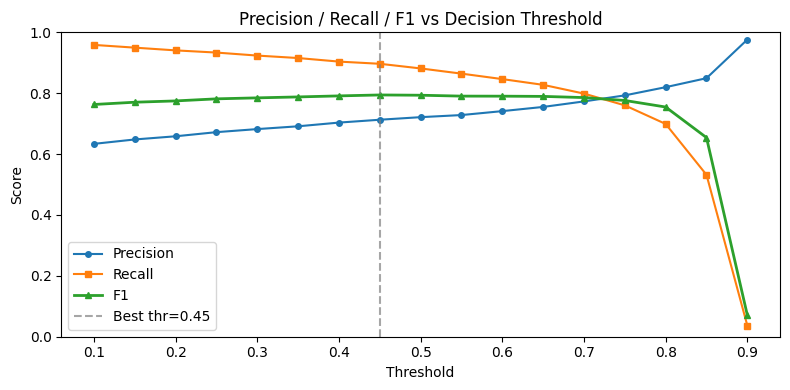

In [13]:
# Visualise precision/recall/F1 vs threshold
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", marker="o", ms=4)
ax.plot(threshold_df["threshold"], threshold_df["recall"],    label="Recall",    marker="s", ms=4)
ax.plot(threshold_df["threshold"], threshold_df["f1"],        label="F1",        marker="^", ms=4, linewidth=2)
ax.axvline(best_thr.threshold, color="grey", linestyle="--", alpha=0.7, label=f"Best thr={best_thr.threshold}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Decision Threshold")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("threshold_curve.png", dpi=150)
plt.show()

## 7 · Error Analysis

In [14]:
# Align raw text with predictions
raw_eval = (
    dataset["validation"]
    .shuffle(seed=SEED)
    .select(range(len(eval_data)))
)

errors_df = pd.DataFrame(raw_eval)
errors_df["pred"]   = preds
errors_df["prob_dup"] = softmax(logits, axis=1)[:, 1].round(3)
errors_df["error_type"] = np.select(
    [
        (errors_df["label"] == 0) & (errors_df["pred"] == 1),
        (errors_df["label"] == 1) & (errors_df["pred"] == 0),
    ],
    ["false_positive", "false_negative"],
    default="correct"
)

print("Error distribution:")
print(errors_df["error_type"].value_counts())

cols = ["question1", "question2", "label", "pred", "prob_dup"]

print("\n── False positives (predicted duplicate, actually NOT) ──")
display(errors_df[errors_df["error_type"] == "false_positive"][cols].head(5))

print("\n── False negatives (predicted NOT duplicate, actually are) ──")
display(errors_df[errors_df["error_type"] == "false_negative"][cols].head(5))

Error distribution:
error_type
correct           2489
false_positive     379
false_negative     132
Name: count, dtype: int64

── False positives (predicted duplicate, actually NOT) ──


,question1,question2,label,pred,prob_dup
0,How do I get rid of anxiety and depression?,"How do I get rid of anxiety, loneliness and de...",0,1,0.851
15,What is the best civilization in Age of Empire...,What is the best civilization in Age of Empire...,0,1,0.733
19,What is the best way to study 5 to 7 hours a day?,How can I study 10+ hours a day?,0,1,0.563
21,How do I make dreams come true successfully?,How can I make my dreams come true?,0,1,0.877
24,Can Rahul Gandhi change the current plight of ...,Massive response for Rahul Gandhi in UP khat y...,0,1,0.814



── False negatives (predicted NOT duplicate, actually are) ──


,question1,question2,label,pred,prob_dup
8,How do I sign out of auora?,How do I log out on Quora?,1,0,0.070
36,What are the pros and cons of buying a used ca...,Is buying used cars from Avis or Hertz a good ...,1,0,0.013
53,What do you think of the new iPhone7 Airpods?,What do you think of Apple's airpods?,1,0,0.142
94,What is the stock market?,What is sensex all about and how to understand...,1,0,0.008
107,What are the best places to visit near Bangalo...,What are some good places to visit near Bengal...,1,0,0.015


In [15]:
# Free GPU memory when done
del model, trainer
torch.cuda.empty_cache()
gc.collect()
print("Done. GPU memory released.")

Done. GPU memory released.
